In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int 
    operation: str 
    number2: int
    number3: int 
    operation2: str 
    number4: int
    finalNumber: int
    finalNumber2: int

In [7]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def adder2(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber2"] = state["number1"] + state["number2"]

    return state

def subtractor2(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber2"] = state["number1"] - state["number2"]
    return state


def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "subtraction_operation" 

def decide_next_node2(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation2"] == "+":
        return "addition_operation2"
    
    elif state["operation2"] == "-":
        return "subtraction_operation2" 


In [8]:
graph = StateGraph(AgentState)

graph.add_node("router1", lambda state:state) # passthrough function
graph.add_node("add_node1", adder)
graph.add_node("subtract_node1", subtractor)

graph.add_node("router2", lambda state:state) # passthrough function
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)

graph.add_edge(START, "router1") 
graph.add_conditional_edges(
    "router1",
    decide_next_node, 
    {
        # Edge: Node
        "addition_operation": "add_node1",
        "subtraction_operation": "subtract_node1"
    }
)

graph.add_edge("add_node1", "router2")
graph.add_edge("subtract_node1", "router2")
graph.add_conditional_edges(
    "router2",
    decide_next_node2, 
    {
        # Edge: Node
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

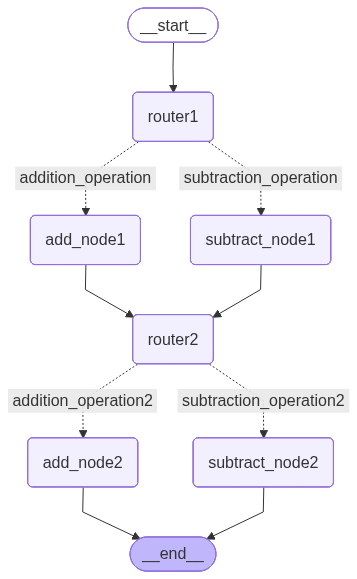

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
initial_state_1 = AgentState(number1 = 10, operation="-", number2 = 5, number3=7, number4=2, operation2="+", finalNumber=0, finalNumber2=0)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'number3': 7, 'operation2': '+', 'number4': 2, 'finalNumber': 5, 'finalNumber2': 15}
